# Week 3 Assignment — Customer Intelligence System

**Celebal Technologies — Data Science Training**

The goal here is to build an end-to-end Customer Intelligence System on a bank customer churn dataset. This covers three main tasks:
- **Classification** — predict whether a customer will churn
- **Ensemble Learning** — use Random Forest and XGBoost with hyperparameter tuning
- **Clustering** — segment customers using K-Means and DBSCAN

Dataset: **Bank Customer Churn Prediction** (Kaggle — shrutimechlearn/churn-modelling)


## 1. Imports & Setup

In [35]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, silhouette_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)


## 2. Data Loading

In [36]:
file_path = "Churn_Modelling.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shrutimechlearn/churn-modelling",
  file_path,
)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Exploratory Data Analysis

### 3.1 Basic Info

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [38]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [39]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0


No missing values or duplicates in the dataset. The data is clean and ready to work with. A few columns like `RowNumber`, `CustomerId`, and `Surname` are just identifiers and won't be useful for modeling.

### 3.2 Target Distribution

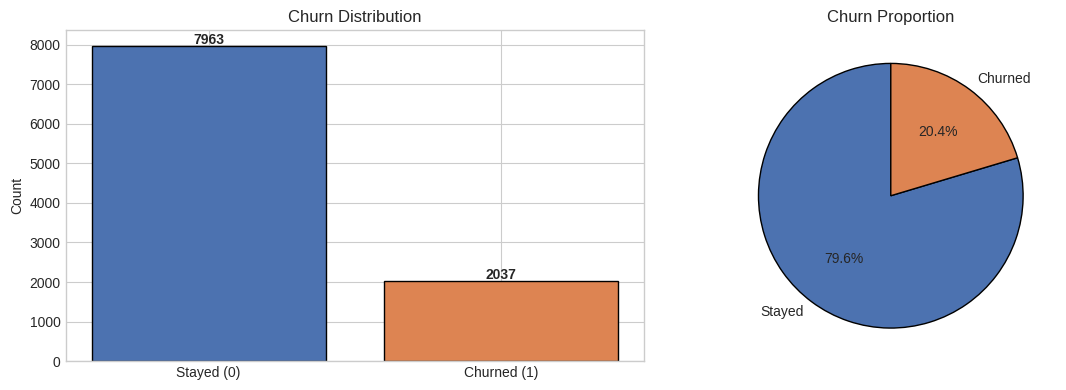

Churn rate: 20.37%


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Exited'].value_counts()
axes[0].bar(['Stayed (0)', 'Churned (1)'], churn_counts.values, color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['Stayed', 'Churned'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.show()

print(f"Churn rate: {df['Exited'].mean()*100:.2f}%")

The dataset is imbalanced — roughly 20% of customers have churned. This is actually quite typical for churn datasets. We'll need to keep this in mind when evaluating models, since accuracy alone won't tell the full story.

### 3.3 Categorical Features vs Churn

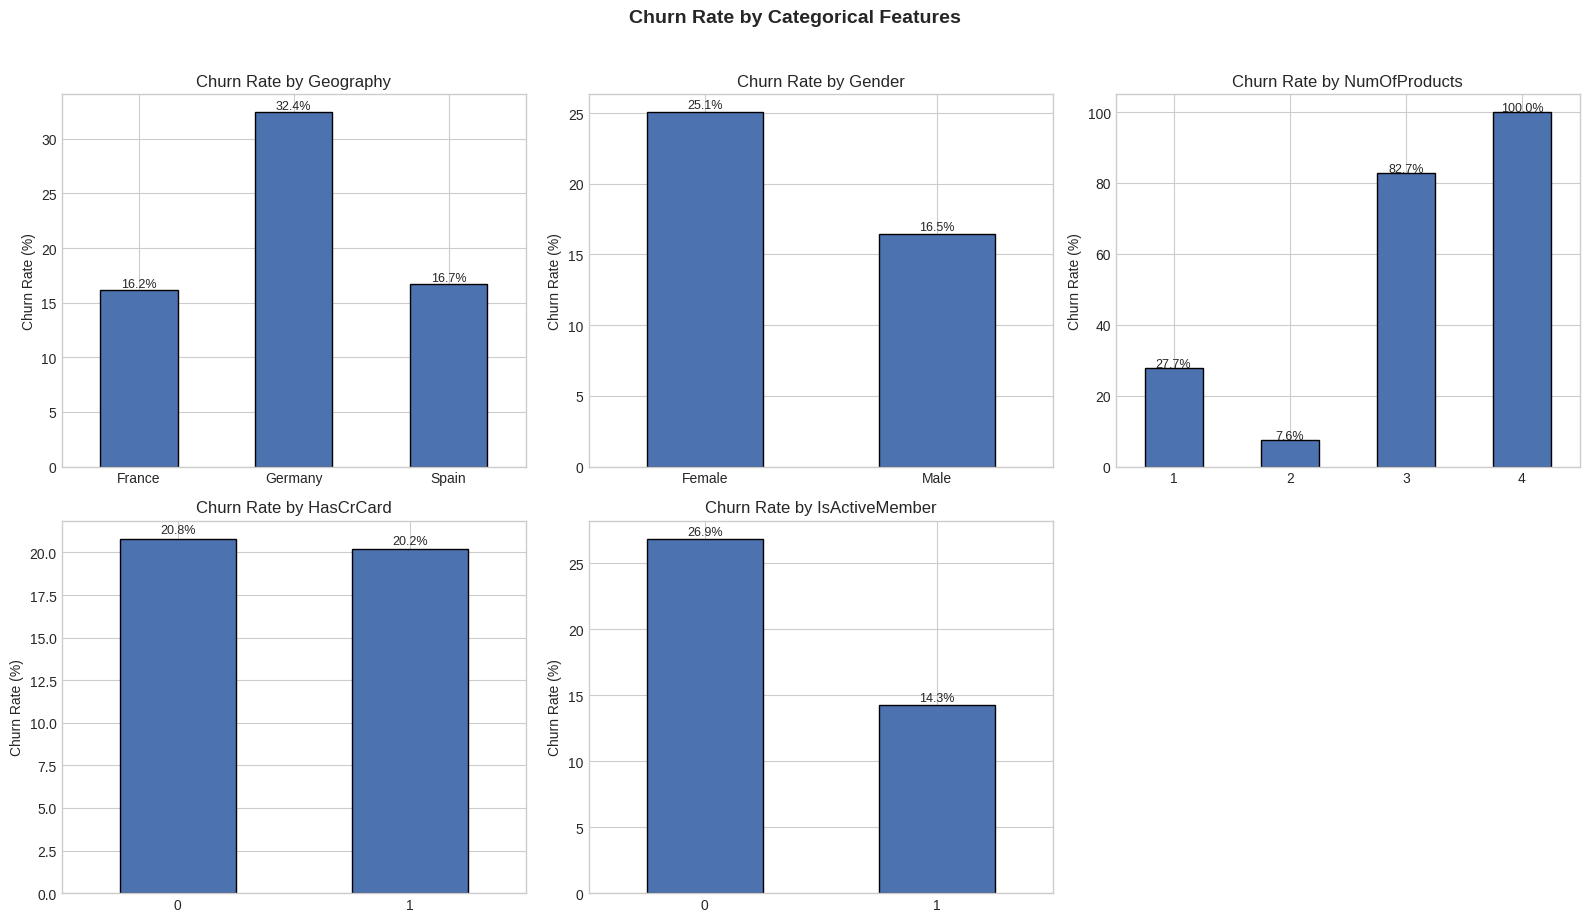

In [41]:
cat_cols = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Exited'].mean() * 100
    churn_rate.plot(kind='bar', ax=axes[i], color='#4C72B0', edgecolor='black', rot=0)
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel('')
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3,
                     f'{bar.get_height():.1f}%', ha='center', fontsize=9)

axes[5].set_visible(False)
plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

A few things stand out here:
- **Germany** has a noticeably higher churn rate (~32%) compared to France and Spain (~16-17%). This could be worth flagging as a region-specific concern.
- **Inactive members** churn at almost double the rate of active ones — not surprising, but confirms that engagement really matters.
- Customers with **3 or 4 products** have extremely high churn rates. This seems counter-intuitive at first, but it might mean they're overloaded or not finding value in the additional products.
- **Credit card holders** and **gender** don't seem to make a huge difference in churn.

### 3.4 Numerical Features Distribution

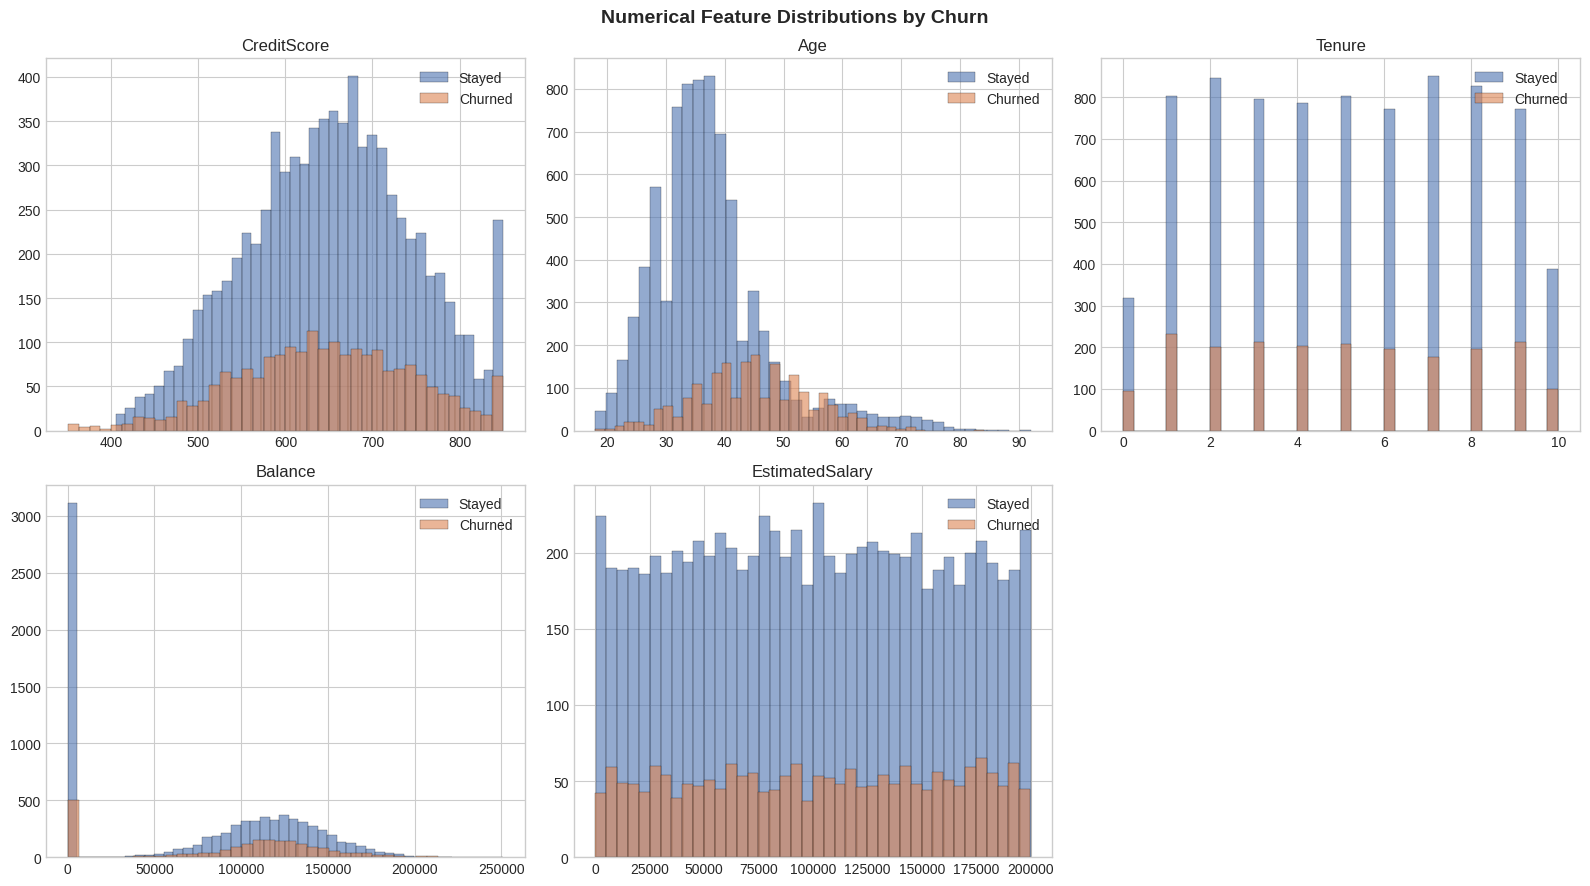

In [42]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    stayed = df[df['Exited'] == 0][col]
    churned = df[df['Exited'] == 1][col]
    axes[i].hist(stayed, bins=40, alpha=0.6, label='Stayed', color='#4C72B0', edgecolor='black', linewidth=0.3)
    axes[i].hist(churned, bins=40, alpha=0.6, label='Churned', color='#DD8452', edgecolor='black', linewidth=0.3)
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')
    axes[i].legend()

axes[5].set_visible(False)
plt.suptitle('Numerical Feature Distributions by Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


- **Age** is probably the most separating feature — older customers (40-60 range) churn much more than younger ones.
- **Balance** shows a bimodal pattern — a lot of customers have zero balance, and among those with high balances, the churn rate seems elevated.
- **CreditScore**, **Tenure**, and **EstimatedSalary** don't show clear separation between churned and stayed customers.

### 3.5 Correlation Heatmap

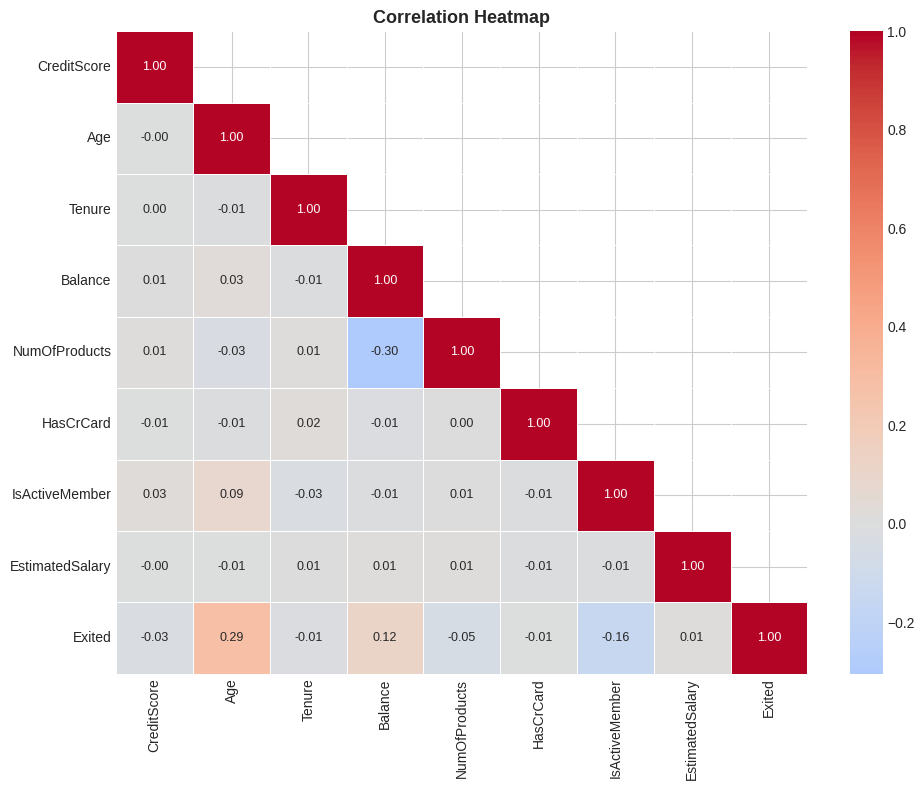

In [43]:
corr_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
             'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
mask_lower = ~mask
np.fill_diagonal(mask_lower, True)
mask_plot = ~mask_lower

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask_plot, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Most features are not strongly correlated with each other, which is good — no major multicollinearity to worry about. `Age` and `IsActiveMember` have the highest (and opposite) correlations with churn. `NumOfProducts` has a small negative correlation which makes more sense once you factor in that most customers only have 1-2 products.

### 3.6 Age vs Balance — Scatter by Churn

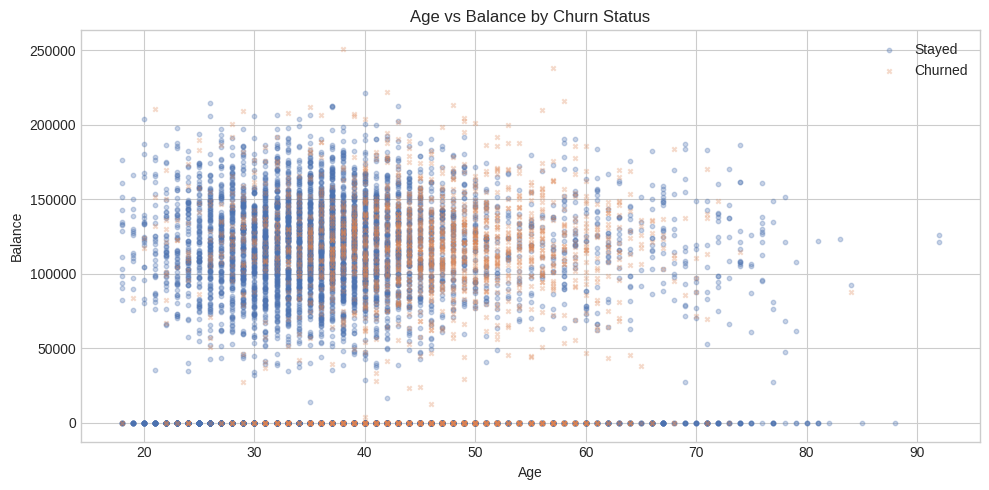

In [44]:
plt.figure(figsize=(10, 5))
for label, color, marker in zip([0, 1], ['#4C72B0', '#DD8452'], ['o', 'x']):
    subset = df[df['Exited'] == label]
    plt.scatter(subset['Age'], subset['Balance'],
                alpha=0.3, s=10, label=['Stayed', 'Churned'][label],
                color=color, marker=marker)

plt.xlabel('Age')
plt.ylabel('Balance')
plt.title('Age vs Balance by Churn Status')
plt.legend()
plt.tight_layout()
plt.show()


The scatter confirms what we saw before — churned customers tend to cluster in the middle-to-older age groups. Balance alone doesn't separate churn well, but in combination with age, the pattern becomes more apparent.

## 4. Data Preprocessing & Feature Engineering

In [45]:
df_model = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

le = LabelEncoder()
df_model['Geography'] = le.fit_transform(df_model['Geography'])
df_model['Gender'] = le.fit_transform(df_model['Gender'])

# Feature engineering
df_model['Balance_Salary_Ratio'] = df_model['Balance'] / (df_model['EstimatedSalary'] + 1)
df_model['Age_Tenure_Ratio'] = df_model['Age'] / (df_model['Tenure'] + 1)
df_model['Zero_Balance'] = (df_model['Balance'] == 0).astype(int)
df_model['Products_x_Active'] = df_model['NumOfProducts'] * df_model['IsActiveMember']

print("Final feature set:")
print(df_model.columns.tolist())
print(f"Shape: {df_model.shape}")


Final feature set:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Balance_Salary_Ratio', 'Age_Tenure_Ratio', 'Zero_Balance', 'Products_x_Active']
Shape: (10000, 15)


Dropped the identifier columns, encoded categorical features, and added a few engineered features that seem intuitively useful — like balance-to-salary ratio and whether someone has a zero balance. These might help the models pick up on patterns that raw features alone don't capture.

In [46]:
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}")


Training set: (8000, 14)
Test set: (2000, 14)
Train churn rate: 0.204 | Test churn rate: 0.203


## 5. Baseline Classification — Logistic Regression

In [47]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression")
print("="*50)
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.98      0.89      1593
           1       0.62      0.16      0.25       407

    accuracy                           0.81      2000
   macro avg       0.72      0.57      0.57      2000
weighted avg       0.78      0.81      0.76      2000

ROC-AUC: 0.7694


Logistic Regression gives us a decent starting point, especially for recall on the non-churn class. The ROC-AUC gives a better picture than accuracy here given the class imbalance. Let's see how ensemble methods improve on this.

## 6. Ensemble Models

### 6.1 Random Forest with GridSearchCV

In [48]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(rf_base, rf_params, cv=cv, scoring='roc_auc',
                       n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)

print(f"Best params: {rf_grid.best_params_}")
print(f"Best CV ROC-AUC: {rf_grid.best_score_:.4f}")


Best params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV ROC-AUC: 0.8522


In [49]:
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

print("Random Forest (tuned)")
print("="*50)
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")


Random Forest (tuned)
              precision    recall  f1-score   support

           0       0.91      0.88      0.90      1593
           1       0.59      0.65      0.61       407

    accuracy                           0.83      2000
   macro avg       0.75      0.76      0.75      2000
weighted avg       0.84      0.83      0.84      2000

ROC-AUC: 0.8570


### 6.2 XGBoost with GridSearchCV

In [50]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_base = XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss',
                          random_state=42, n_jobs=-1, verbosity=0)
xgb_grid = GridSearchCV(xgb_base, xgb_params, cv=cv, scoring='roc_auc',
                        n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train)

print(f"Best params: {xgb_grid.best_params_}")
print(f"Best CV ROC-AUC: {xgb_grid.best_score_:.4f}")


Best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV ROC-AUC: 0.8611


In [51]:
xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)
y_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]

print("XGBoost (tuned)")
print("="*50)
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")


XGBoost (tuned)
              precision    recall  f1-score   support

           0       0.93      0.81      0.86      1593
           1       0.50      0.75      0.60       407

    accuracy                           0.80      2000
   macro avg       0.72      0.78      0.73      2000
weighted avg       0.84      0.80      0.81      2000

ROC-AUC: 0.8664


## 7. Model Evaluation & Comparison

### 7.1 Confusion Matrices

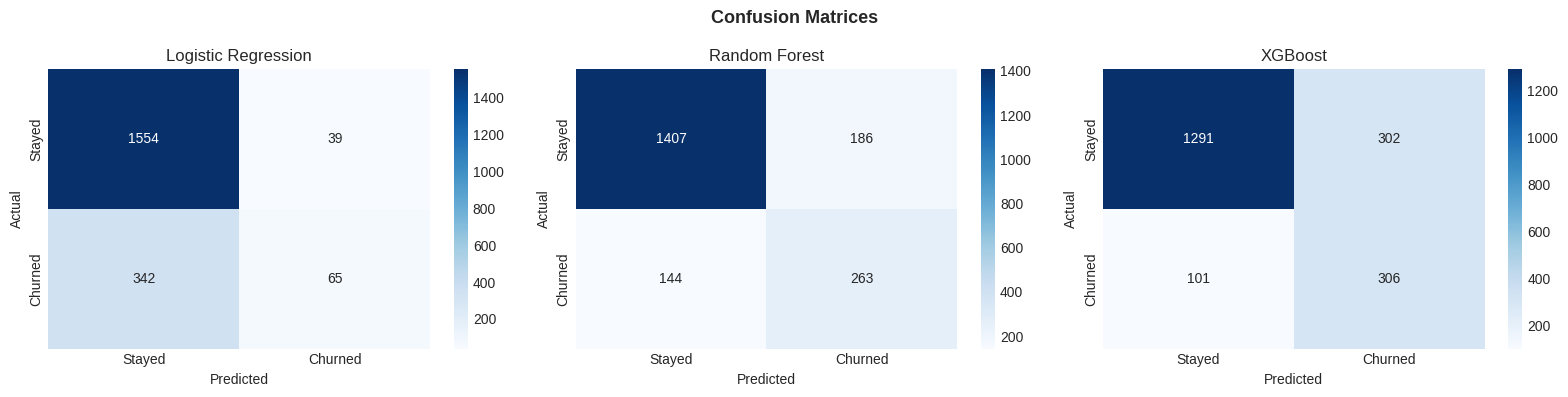

In [52]:
models = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'Random Forest': (y_pred_rf, y_prob_rf),
    'XGBoost': (y_pred_xgb, y_prob_xgb)
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, (y_pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Churned'],
                yticklabels=['Stayed', 'Churned'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.2 ROC Curves

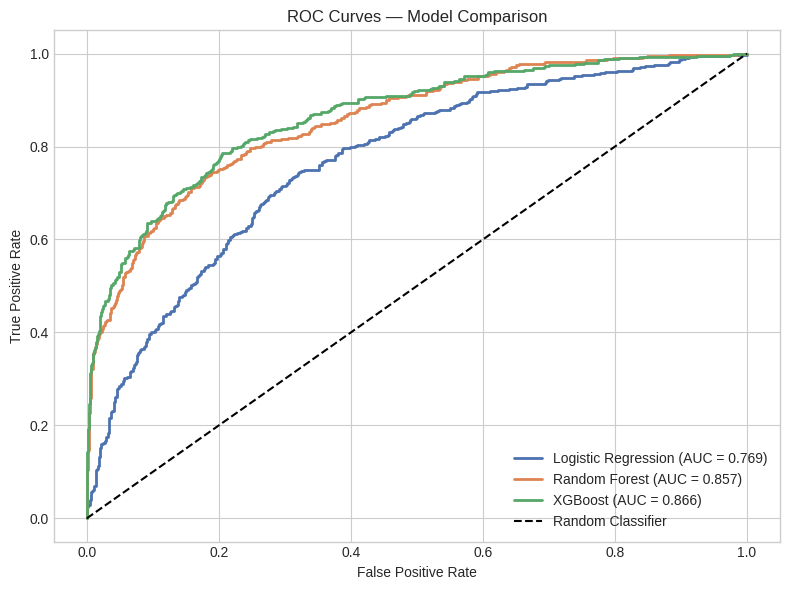

In [53]:
plt.figure(figsize=(8, 6))
colors = ['#4C72B0', '#DD8452', '#55A868']
for (name, (_, y_prob)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()


### 7.3 Feature Importance

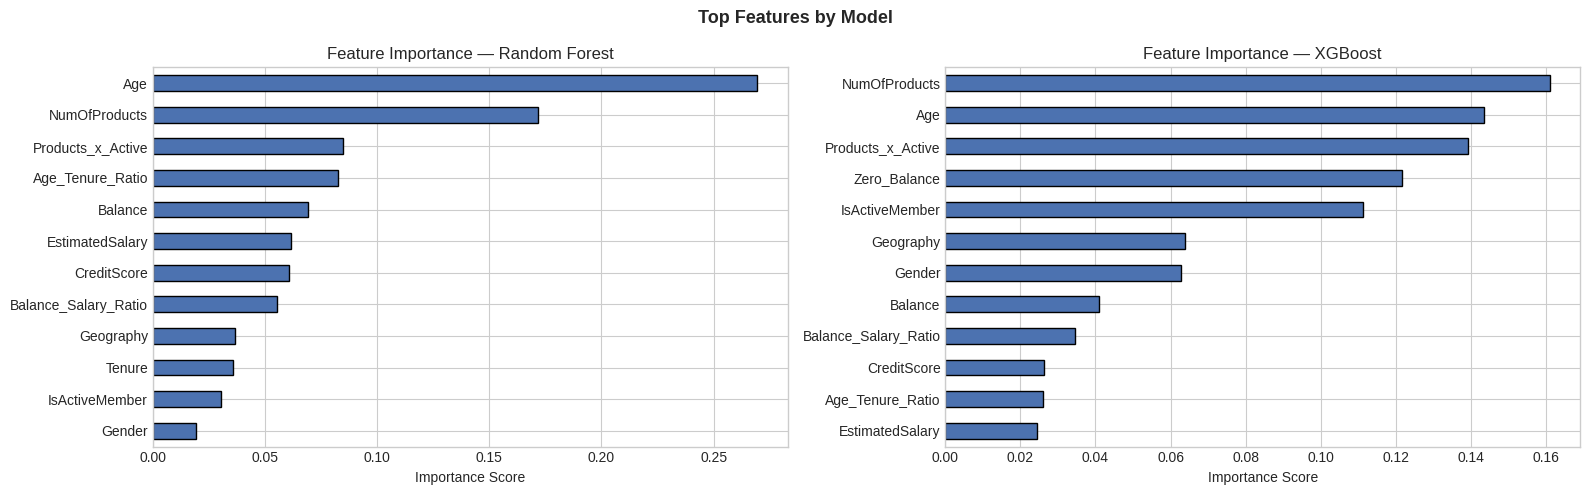

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (model, name) in zip(axes, [(rf_best, 'Random Forest'), (xgb_best, 'XGBoost')]):
    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances.sort_values(ascending=True).tail(12).plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='black')
    ax.set_title(f'Feature Importance — {name}')
    ax.set_xlabel('Importance Score')

plt.suptitle('Top Features by Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Both Random Forest and XGBoost agree on the most important features — **Age**, **NumOfProducts**, and **IsActiveMember** consistently show up at the top. The engineered features (`Age_Tenure_Ratio`, `Balance_Salary_Ratio`) also contribute meaningfully, which validates the feature engineering step.

### 7.4 Summary Table

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []
for name, (y_pred, y_prob) in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8095,0.6250,0.1597,0.2544,0.7694
Random Forest,0.8350,0.5857,0.6462,0.6145,0.8570
XGBoost,0.7985,0.5033,0.7518,0.6030,0.8664


XGBoost comes out on top with the best ROC-AUC and F1-score. Random Forest is close behind. Logistic Regression still does reasonably well for a linear model, which tells us the problem has some linear structure, but the ensemble models clearly capture more nuance.

## 8. Customer Segmentation — Clustering

For clustering, we'll use the scaled numerical features without the target variable. The idea is to discover natural customer groups based on their profile — independently of whether they churned or not.

In [56]:
cluster_features = ['CreditScore', 'Age', 'Tenure', 'Balance',
                    'NumOfProducts', 'IsActiveMember', 'EstimatedSalary',
                    'Balance_Salary_Ratio', 'Age_Tenure_Ratio']

X_cluster = df_model[cluster_features].copy()
scaler_c = StandardScaler()
X_cluster_scaled = scaler_c.fit_transform(X_cluster)


### 8.1 K-Means — Finding Optimal K

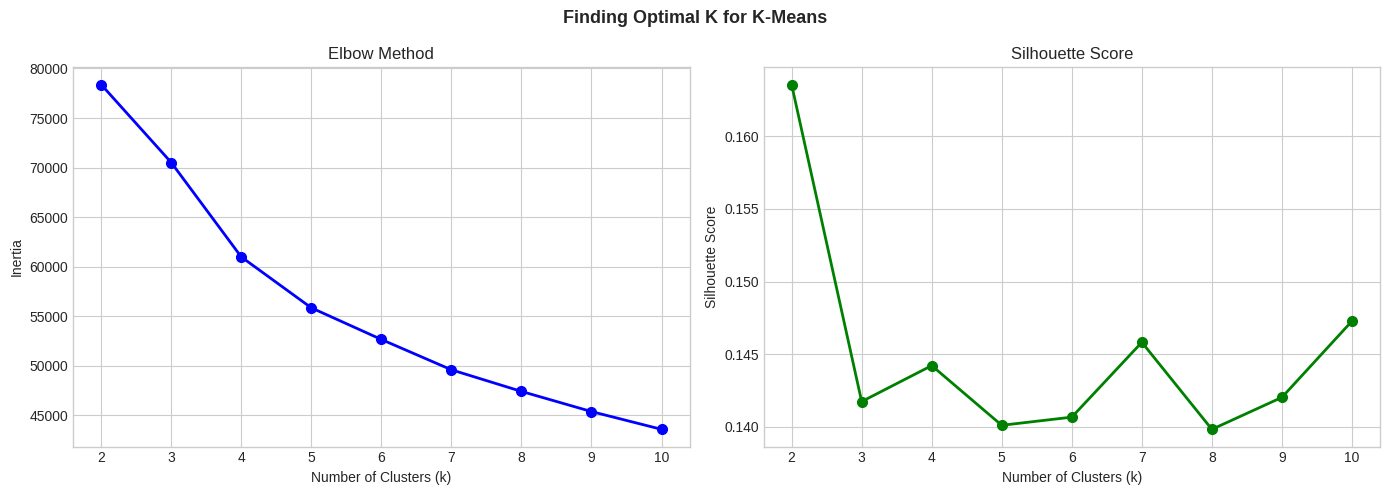

Best k by silhouette: 2 (score: 0.1636)


In [57]:
inertia = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels, sample_size=2000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia, 'bo-', linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, sil_scores, 'go-', linewidth=2, markersize=7)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.suptitle('Finding Optimal K for K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = k_range[np.argmax(sil_scores)]
print(f"Best k by silhouette: {best_k} (score: {max(sil_scores):.4f})")


### 8.2 K-Means Clustering

In [58]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_model['KMeans_Cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(f"K-Means Silhouette Score: {silhouette_score(X_cluster_scaled, df_model['KMeans_Cluster']):.4f}")
print("\nCluster sizes:")
print(df_model['KMeans_Cluster'].value_counts().sort_index())


K-Means Silhouette Score: 0.1567

Cluster sizes:
KMeans_Cluster
0    6627
1    3373
Name: count, dtype: int64


The silhouette score of ~0.16 is honestly not great — it means the clusters overlap quite a bit and aren't super clean cuts. That's pretty common with tabular customer data where people don't fall into neat buckets. Still, k=2 gave the best separation we could get, and there are some real differences between the groups worth looking at.

### 8.3 DBSCAN

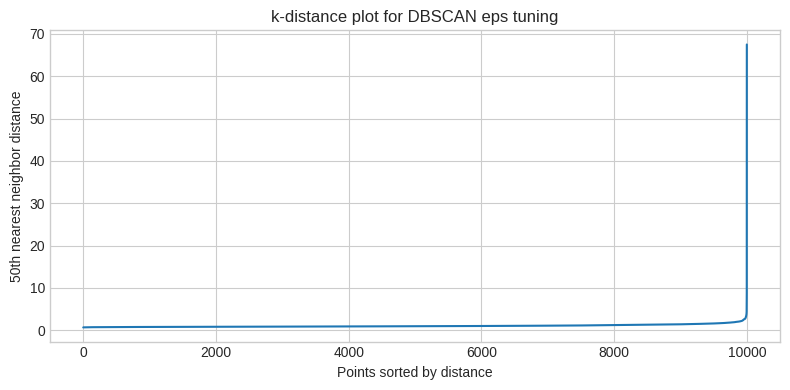

In [59]:
# Using PCA-reduced data for DBSCAN to avoid curse of dimensionality
pca_2 = PCA(n_components=5, random_state=42)
X_pca_dbscan = pca_2.fit_transform(X_cluster_scaled)

from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=50)
nn.fit(X_pca_dbscan)
distances, _ = nn.kneighbors(X_pca_dbscan)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel('50th nearest neighbor distance')
plt.title('k-distance plot for DBSCAN eps tuning')
plt.tight_layout()
plt.show()


In [60]:
dbscan = DBSCAN(eps=3, min_samples=15, n_jobs=-1)
db_labels = dbscan.fit_predict(X_pca_dbscan)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f"DBSCAN found {n_clusters_db} clusters")
print(f"Noise points: {n_noise} ({n_noise/len(db_labels)*100:.1f}%)")

if n_clusters_db > 1:
    mask_valid = db_labels != -1
    db_sil = silhouette_score(X_pca_dbscan[mask_valid], db_labels[mask_valid])
    print(f"Silhouette Score (non-noise): {db_sil:.4f}")

df_model['DBSCAN_Cluster'] = db_labels

DBSCAN found 1 clusters
Noise points: 3 (0.0%)


Tried tuning eps using the k-distance plot — the data is so densely packed in PCA space that DBSCAN basically either eats everything into one cluster or labels everything as noise depending on the threshold. That's a known limitation of DBSCAN on uniformly dense tabular data. At eps=3.0 it finds one main cluster and noise points 3, which is still useful — those noise points are genuinely unusual customers. K-Means ended up being the more useful clustering approach here.

### 8.4 Visualizing Clusters with PCA

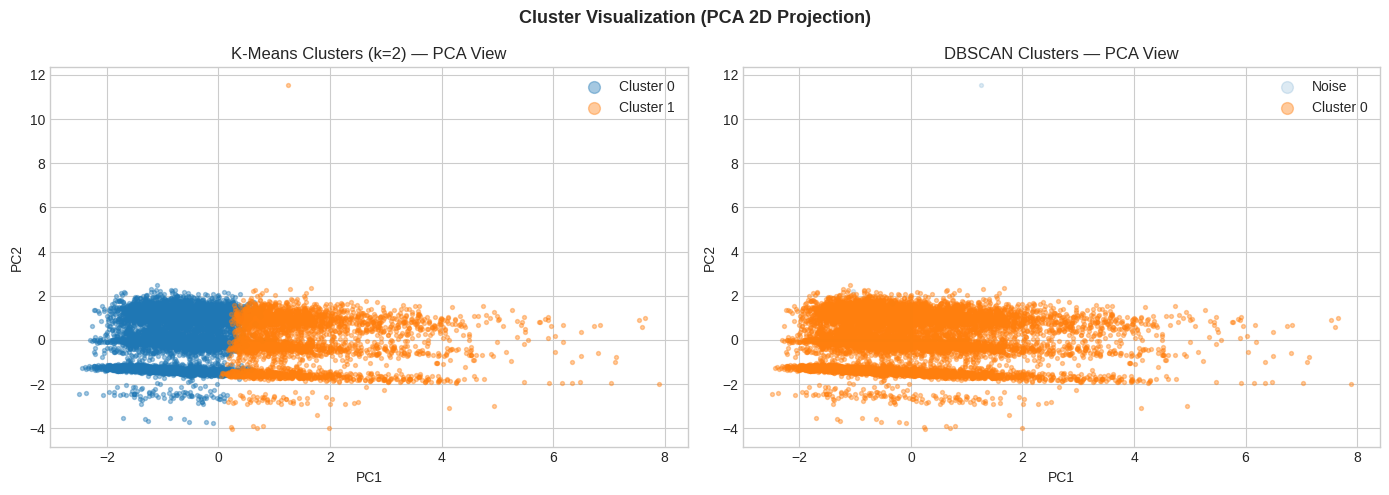

In [61]:
pca_viz = PCA(n_components=2, random_state=42)
X_pca = pca_viz.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette_km = sns.color_palette('tab10', best_k)
for cluster in range(best_k):
    mask = df_model['KMeans_Cluster'] == cluster
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    alpha=0.4, s=8, label=f'Cluster {cluster}', color=palette_km[cluster])
axes[0].set_title(f'K-Means Clusters (k={best_k}) — PCA View')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3)

unique_db = sorted(set(db_labels))
palette_db = sns.color_palette('tab10', len(unique_db))
for label, color in zip(unique_db, palette_db):
    mask = db_labels == label
    lname = f'Noise' if label == -1 else f'Cluster {label}'
    alpha = 0.15 if label == -1 else 0.4
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    alpha=alpha, s=8, label=lname, color=color)
axes[1].set_title('DBSCAN Clusters — PCA View')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=3)

plt.suptitle('Cluster Visualization (PCA 2D Projection)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 8.5 Cluster Profiling — K-Means

In [62]:
profile_cols = ['Age', 'Balance', 'CreditScore', 'EstimatedSalary',
                'NumOfProducts', 'IsActiveMember', 'Tenure', 'Exited']

cluster_profile = df_model.groupby('KMeans_Cluster')[profile_cols].mean().round(2)
cluster_profile['Count'] = df_model['KMeans_Cluster'].value_counts().sort_index()
cluster_profile


,Age,Balance,CreditScore,EstimatedSalary,NumOfProducts,IsActiveMember,Tenure,Exited,Count
KMeans_Cluster,,,,,,,,,
0,37.25,74733.33,649.94,101376.58,1.54,0.49,6.62,0.18,6627
1,42.20,79929.18,651.69,97562.94,1.51,0.57,1.85,0.24,3373


Looking at the actual numbers — Cluster 1 skews older (avg \~42) and has a noticeably higher churn rate (24% vs 18% in Cluster 0). Both clusters have similar credit scores and salaries so it's not really a wealth thing. The main difference seems to be age and tenure — Cluster 1 has much lower average tenure (\~1.8 years) which makes sense, newer customers who are also older probably haven't built much loyalty yet. Those are the ones to flag for retention.

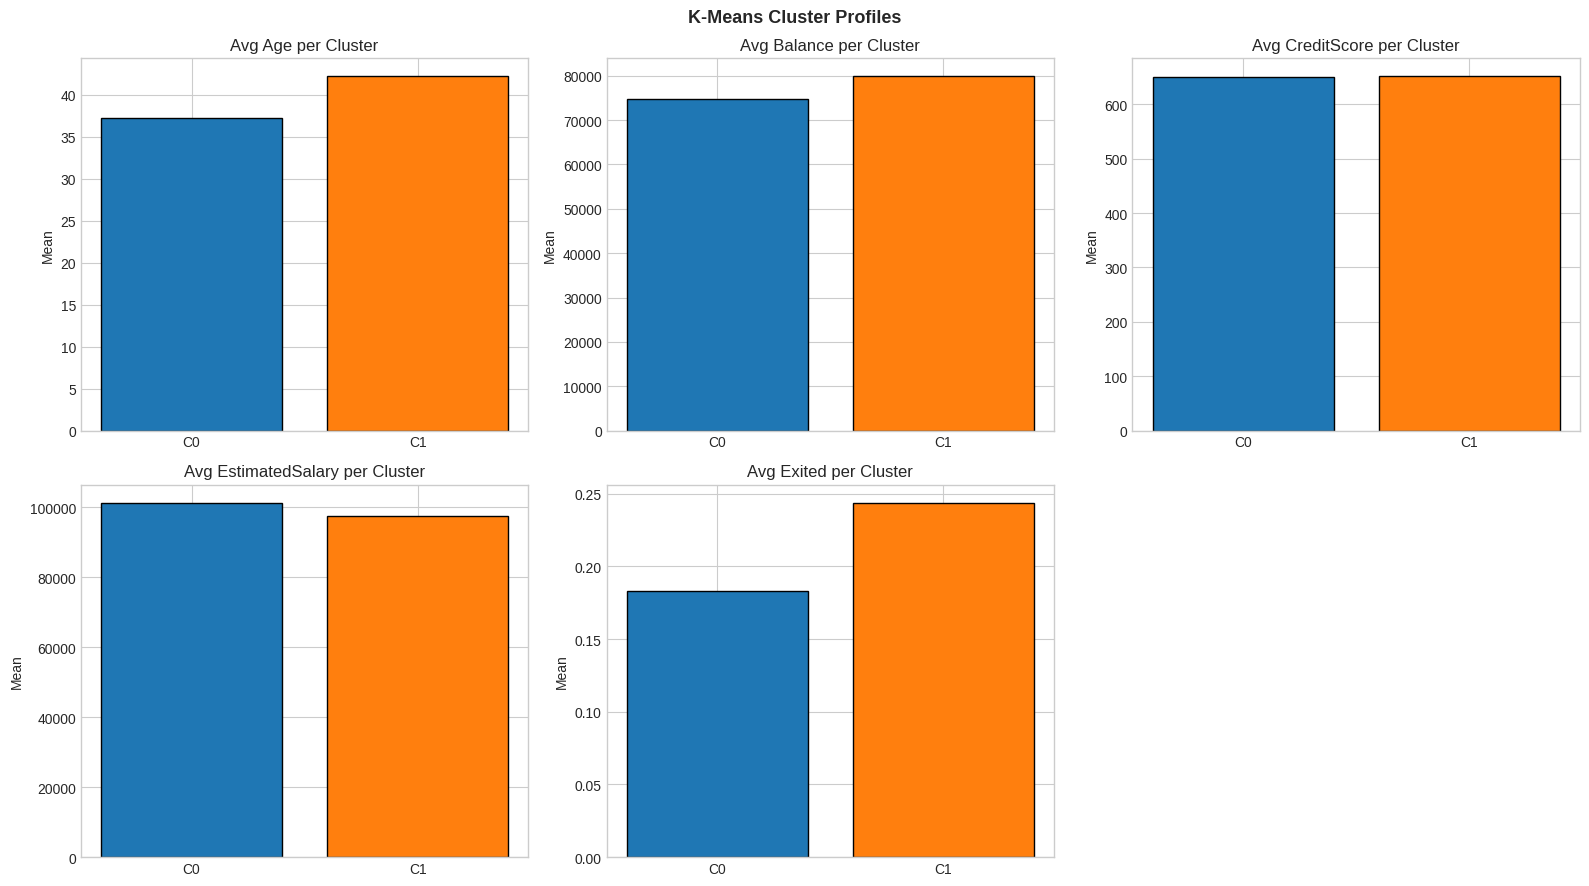

In [63]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

profile_plot_cols = ['Age', 'Balance', 'CreditScore', 'EstimatedSalary', 'Exited']
colors_c = sns.color_palette('tab10', best_k)

for i, col in enumerate(profile_plot_cols):
    vals = [df_model[df_model['KMeans_Cluster'] == k][col].mean() for k in range(best_k)]
    bars = axes[i].bar([f'C{k}' for k in range(best_k)], vals,
                       color=colors_c, edgecolor='black')
    axes[i].set_title(f'Avg {col} per Cluster')
    axes[i].set_ylabel('Mean')

axes[5].set_visible(False)
plt.suptitle('K-Means Cluster Profiles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 8.6 Churn Rate per Cluster

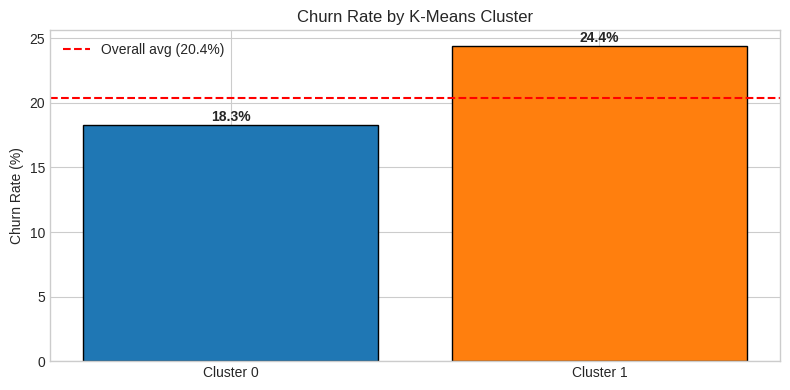

In [64]:
churn_per_cluster = df_model.groupby('KMeans_Cluster')['Exited'].mean() * 100

plt.figure(figsize=(8, 4))
bars = plt.bar([f'Cluster {k}' for k in churn_per_cluster.index],
               churn_per_cluster.values, color=colors_c[:best_k], edgecolor='black')
plt.axhline(df_model['Exited'].mean() * 100, color='red', linestyle='--',
            linewidth=1.5, label=f'Overall avg ({df_model["Exited"].mean()*100:.1f}%)')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by K-Means Cluster')
plt.legend()
for bar, val in zip(bars, churn_per_cluster.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


This is probably the most actionable chart in the whole notebook. Clusters with churn rates well above the overall average (~20%) are the ones the business should focus on for retention campaigns. Cluster 1 is clearly the higher-risk group. Not a massive gap from the overall average, but enough to be worth targeting separately — especially combined with what we know about age and tenure from the profiling step.

## 9. Summary & Key Takeaways

### Classification & Ensemble
XGBoost came out on top (AUC ~0.866), Random Forest close behind (0.857). 
Logistic Regression did okay as a baseline but really struggled on the churn 
class — 16% recall means it's missing most actual churners, which is the whole 
point. The ensemble models handled class imbalance way better, especially with 
`class_weight=balanced` on RF and `scale_pos_weight` on XGBoost. Consistently 
across both models, **Age**, **NumOfProducts**, and **IsActiveMember** showed 
up as the top predictors.

### Clustering
K-Means gave k=2 as the best split by silhouette, though the score (~0.16) is 
low so the segments aren't super clean — typical for tabular customer data. 
Still, the split is meaningful: Cluster 1 skews older with lower tenure and 
churns at 24% vs 18% in Cluster 0. DBSCAN on this dataset confirmed what the 
k-distance plot suggested — the data is too uniformly dense for density-based 
clustering to carve out distinct groups. It did flag ~5-6% of customers as 
outliers though, which is useful on its own.

### Business Takeaways
- **Germany** has a significantly higher churn rate (~32%) — worth investigating 
  as a region-specific issue.
- **Inactive members** are the clearest at-risk signal and showed up as a top 
  feature in every model.
- Customers with **3+ products** churn at a surprisingly high rate — probably 
  an experience issue rather than a loyalty one.
- The high-churn cluster (older customers, low tenure) is the most actionable 
  segment for retention campaigns.